In [4]:
###-----------------
### Import Libraries
###-----------------

from pathlib import Path  # Import Path for file system path operations and management
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split  # for train-test splitting
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score,ConfusionMatrixDisplay


import torch
import torch.nn as nn
from torchsummary import summary
from collections.abc import Callable    # type hinting callable objects/functions
from typing import Literal      # literal type hints to restrict variable values

from torch.utils.data import Dataset, DataLoader




In [5]:
###----------------------
### Some basic parameters
###----------------------

# inpDir = Path('..') / '..' / 'input'
# outDir = Path('..') / 'output'
# modelDir = Path('..') / 'models'
# subDir = 'fifa_2019'

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
np.random.seed(RANDOM_STATE)
# rng = np.random.default_rng(seed = RANDOM_STATE) # Set Random Seed for reproducible  results

EPOCHS = 101 # number of epochs


BATCH_SIZE = 32              # <------- Look at TRAIN_SIZE too
ALPHA = 0.001 # learning rate
# TEST_SIZE = 0.2
TRAIN_SIZE=453* BATCH_SIZE     #<---- good for BATCH_SIZE=32

# parameters for Matplotlib
params = {'legend.fontsize': 'medium',
          'figure.figsize': (15, 6),
          'axes.labelsize': 'medium',
          'axes.titlesize':'x-large',
          'xtick.labelsize':'medium',
          'ytick.labelsize':'medium'
         }

plt.rcParams.update(params)

CMAP = plt.cm.coolwarm
plt.style.use('seaborn-v0_8-darkgrid') # plt.style.use('ggplot')

In [3]:
# Check if all directories are present
# outDir.mkdir(parents=True, exist_ok=True)

# modelSubDir = modelDir/ subDir
# modelSubDir.mkdir(parents=True, exist_ok=True)

In [10]:
data_df = pd.read_csv('./fashion-mnist_train.csv',header=0)
data_df.shape

(60000, 785)

In [11]:
#class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
#               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

class_names = {0: 'T-shirt/top',1:'Trouser',2:'Pullover',3:'Dress',4:'Coat',
               5:'Sandal', 6: 'Shirt',7: 'Sneaker', 8:'Bag', 9: 'Ankle boot'}

In [11]:
X_train = data_df.drop('label', axis = 1).to_numpy()
y_train = data_df['label'].to_numpy()

X_test = test_df.drop('label', axis = 1).to_numpy()
y_test = test_df['label'].to_numpy()

X_train.shape, X_test.shape, y_train.shape, y_test.shape

NameError: name 'train_df' is not defined

In [12]:
# splitting in train ans test datasets
X_train,X_test,y_train,y_test = train_test_split(features,labels,
                                     stratify=labels,
                                     train_size=TRAIN_SIZE, 
                                     random_state=RANDOM_STATE )
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((14496, 33), (3651, 33), (14496,), (3651,))

In [13]:
list(class_names.keys())

[0, 1, 2, 3]

In [14]:
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [15]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


### dataset

In [16]:
#every time we request it will give batch of random 32 rows from dataset
class IonoDataset(Dataset):

    def __init__(self,
                 dataframe: pd.DataFrame,
                 device: str=device,
                 is_train=True,
                 label_col=None,
                 transformer=None):
        super(IonoDataset,self).__init__()
        self.df=dataFrame
        self.device=device
        self.is_train=is_train
        self.label_col=label_col
        self.transformer=transformer

        self.features=self.df.drop(label_col,axis=1).to_numpy()
        self.features=se;f.geatures / 255
        y=self.df[label_col].to_numpy()
        
        self.X= torch.tensor(X, dtype=torch.float32)
        self.y= torch.tensor(y, dtype=torch.long)

        # if self.is train_df.head()train:
        #     self.transformer=DataTransformer()
        #     self.features, self.labels=self.transformer.fit_transform(X,y)
        # else:
        #     if self.transformer is None:
        #         raise

    def __len__(self):
        return len(self.features)

    def __getitem__(self,index):
        features=self.features[index]
        lebels=self.labels[index]
        features=torch.tensor(features,dtype=torch.float32)
        labels=torch.tensor(labels,dtype=torch.int64)
        return features, labels

In [1]:
class IonoModel(nn.Module):

    '''Layers:
    33  -> 16 -> 8-> 4
    
    '''
    def __init__(self,input_dim):
        super(IonoModel,self).__init__()
        self.dor1=0.05
        self.dor2=0.15
        self.dor3=0.25
        
        self.layer1=nn.Linear(input_dim,26)
        self.bn1=nn.BatchNormid(26)
        self.active1=nn.ReLU()
        self.do1=nn.Dropout(self.dor1)
        
        self.layer2=nn.Linear(26,18)
        self.bn2=nn.BatchNormid(18)
        self.active2=nn.ReLU()
        self.do2=nn.Dropout(self.dor2)

        self.layer3=nn.Linear(18,10)
        self.bn3=nn.BatchNormid(10)
        self.active3=nn.ReLU()
        self.do3=nn.Dropout(self.dor3)

        self.layer4=nn.Linear(10,2)
        
    def forward(self,x):
        x=self.do1(self.activ1(self.bn1(self.layer1(x))))
        x=self.do2(self.activ2(self.bn2(self.layer2(x))))
        x=self.do3(self.activ3(self.bn3(self.layer3(x))))
        x=self.layer4(x)
        return x
input_dim=34
model=IonoModel(input_dim=input_dim).to(device=device)

print(model)

NameError: name 'nn' is not defined

In [ ]:
Label_col=34
train_dsIonoModel(train_df,batch_size=True,label_col=label_col)
test_ds=IonoModel(test_df,is-train=False,label_col=label_col,transformer=train_ds.transformer)


In [ ]:
train_loader=DataLoader(train_ds,
                       batch_size=True,
                       shuffle=True)


In [17]:
train_dataset=FifaDataset(X_train,y_train)

#dataloader shuffles the data
train_loader=DataLoader(dataset=train_dataset,batch_size=BATCH_SIZE, shuffle=True)

In [18]:
#ways to select batch
# 1.complete dataset- everytime u take unique 32 rows,
# 2. everytime u select at random but from same lot, rows can be repeated
# *gpu works very well with 2 raise to power something, so select rows in 2^
# #last batch should be full batch size as previous batches, 
#less rows in last batch may create problem, they may give more importance
for batch_idx, (data,target) in enumerate(train_loader):
    print(f'Batch: {batch_idx +1}: ', end=' ')
    print(f'data: {data.shape}: ', end=' ')
    print(f'Target: {target.shape}: ')
    

Batch: 1:  data: torch.Size([32, 33]):  Target: torch.Size([32]): 
Batch: 2:  data: torch.Size([32, 33]):  Target: torch.Size([32]): 
Batch: 3:  data: torch.Size([32, 33]):  Target: torch.Size([32]): 
Batch: 4:  data: torch.Size([32, 33]):  Target: torch.Size([32]): 
Batch: 5:  data: torch.Size([32, 33]):  Target: torch.Size([32]): 
Batch: 6:  data: torch.Size([32, 33]):  Target: torch.Size([32]): 
Batch: 7:  data: torch.Size([32, 33]):  Target: torch.Size([32]): 
Batch: 8:  data: torch.Size([32, 33]):  Target: torch.Size([32]): 
Batch: 9:  data: torch.Size([32, 33]):  Target: torch.Size([32]): 
Batch: 10:  data: torch.Size([32, 33]):  Target: torch.Size([32]): 
Batch: 11:  data: torch.Size([32, 33]):  Target: torch.Size([32]): 
Batch: 12:  data: torch.Size([32, 33]):  Target: torch.Size([32]): 
Batch: 13:  data: torch.Size([32, 33]):  Target: torch.Size([32]): 
Batch: 14:  data: torch.Size([32, 33]):  Target: torch.Size([32]): 
Batch: 15:  data: torch.Size([32, 33]):  Target: torch.Si

In [19]:
X_train.shape, X_test.shape

((14496, 33), (3651, 33))

In [20]:
test_dataset=FifaDataset(X_test,y_test.to_numpy())
test_loader=DataLoader(dataset=test_dataset,batch_size=BATCH_SIZE, shuffle=True)

In [21]:
for batch_idx, (data,target) in enumerate(test_loader):
    print(f'Batch: {batch_idx +1}: ', end=' ')
    print(f'data: {data.shape}: ', end=' ')
    print(f'Target: {target.shape}: ')
    

Batch: 1:  data: torch.Size([32, 33]):  Target: torch.Size([32]): 
Batch: 2:  data: torch.Size([32, 33]):  Target: torch.Size([32]): 
Batch: 3:  data: torch.Size([32, 33]):  Target: torch.Size([32]): 
Batch: 4:  data: torch.Size([32, 33]):  Target: torch.Size([32]): 
Batch: 5:  data: torch.Size([32, 33]):  Target: torch.Size([32]): 
Batch: 6:  data: torch.Size([32, 33]):  Target: torch.Size([32]): 
Batch: 7:  data: torch.Size([32, 33]):  Target: torch.Size([32]): 
Batch: 8:  data: torch.Size([32, 33]):  Target: torch.Size([32]): 
Batch: 9:  data: torch.Size([32, 33]):  Target: torch.Size([32]): 
Batch: 10:  data: torch.Size([32, 33]):  Target: torch.Size([32]): 
Batch: 11:  data: torch.Size([32, 33]):  Target: torch.Size([32]): 
Batch: 12:  data: torch.Size([32, 33]):  Target: torch.Size([32]): 
Batch: 13:  data: torch.Size([32, 33]):  Target: torch.Size([32]): 
Batch: 14:  data: torch.Size([32, 33]):  Target: torch.Size([32]): 
Batch: 15:  data: torch.Size([32, 33]):  Target: torch.Si

# Defne model

In [22]:
#in sequnettial class, all layers given in sequence, one by one layer,
# but if we want to jump from layer 1 to layer 3 it is not possibl
# , for use below and other methods also available


class FifaModel(nn.Module):

    '''Layers:
    33  -> 16 -> 8-> 4
    
    '''
    def __init__(self,input_dim):
        super(FifaModel,self).__init__()
        self.layer1=nn.Linear(input_dim,16)
        self.active1=nn.ReLU()
        
        self.layer2=nn.Linear(16,8)
        self.active2=nn.ReLU()

        self.layer3=nn.Linear(8,4)

    def forward(self,x):
        x=self.layer1(x)
        x=self.active1(x)
        x=self.layer2(x)
        x=self.active2(x)
        x=self.layer3(x)

        return x

    
        
        

In [23]:
model=FifaModel(input_dim=X_train.shape[1]).to(device=device)


In [26]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(), lr=ALPHA)

loss, tloss, n_epoch, acc, tacc=[],[],[],[],[]

for epoch in range(EPOCHS):
    model.train()

    epoch_loss = 0
    epoch_acc = 0
    tepoch_loss = 0
    tepoch_acc = 0

    for batch_idx,(train_X, train_y) in enumerate(train_loader):
        train_X,train_y = train_X.to(device), train_y.to(device)
        predict_prob = model(train_X)
        batch_loss = loss_fn(predict_prob,train_y)
        epoch_loss += (batch_loss-epoch_loss)/(batch_idx+1)

# '''epoch loss started with 0, batch loss is calculated,
#         in first loop-epoch loss= batch loss
# epoch-loss = average of batch loss in one complete paas(epcoh)
#        '''

        #backward propagation
        optimizer.zero_grad()
        batch_loss.backward()
        optimizer.step()


        #collecting the predictions and calculating accuracy
        _, y_pred = torch.max(predict_prob,1)
        batch_acc= accuracy_score(train_y.cpu().numpy(),y_pred.data.cpu())

        epoch_acc += (batch_acc -epoch_acc)/(batch_idx +1 )

    loss.append(epoch_loss.data.item())
    acc.append(epoch_acc)

    
    model.eval()

    with torch.inference_mode():
        for batch_idx, (test_X,test_y) in enumerate(test_loader):
            test_X,test_y=test_X.to(device) ,test_y.to(device)
            predict_prob_tst=model(test_X)
            tbatch_loss= loss_fn(predict_prob_tst,test_y)
            tepoch_loss += (tbatch_loss -tepoch_loss)/ (batch_idx+1)

             #collecting the predictions and calculating accuracy
            _, y_pred = torch.max(predict_prob_tst,1)
            tbatch_acc= accuracy_score(test_y.cpu().numpy(),y_pred.data.cpu())
            tepoch_acc += (tbatch_acc -tepoch_acc)/(batch_idx +1 )
        tloss.append(tepoch_loss.data.item())
        tacc.append(tepoch_acc)
    n_epoch.append(epoch)

    if epoch % 20==0:
        fmtStr= 'Epoch:{:5d}/{:5d} | Loss: {:.5f}/{:.5f} | Accuracy: {:.5f}/{:.5f}'
        print(fmtStr.format(epoch, EPOCHS,
                            epoch_loss.data.item(), 
                            tepoch_loss.data.item(),
                           epoch_acc,tepoch_acc))
        

Epoch:    0/  101 | Loss: 0.25520/0.31130 | Accuracy: 0.89576/0.87527
Epoch:   20/  101 | Loss: 0.25136/0.32297 | Accuracy: 0.89742/0.87156
Epoch:   40/  101 | Loss: 0.25020/0.31940 | Accuracy: 0.89970/0.87255
Epoch:   60/  101 | Loss: 0.24845/0.31897 | Accuracy: 0.89708/0.87310
Epoch:   80/  101 | Loss: 0.24690/0.32212 | Accuracy: 0.90066/0.87120
Epoch:  100/  101 | Loss: 0.24611/0.32630 | Accuracy: 0.89970/0.87147


In [29]:
loss_df= pd.DataFrame({'epoch': n_epoch,
                      'loss':loss,
                      'test_loss':tloss,
                     'acc':acc,
                      'test_acc': tacc})

loss_df.head()

,epoch,loss,test_loss,acc,test_acc
0,0,0.255195,0.311304,0.895764,0.875272
1,1,0.254768,0.313017,0.896247,0.874547
2,2,0.254241,0.311828,0.896730,0.872101
3,3,0.253162,0.316043,0.896592,0.870199
4,4,0.253544,0.311057,0.896316,0.873641


In [46]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd
import matplotlib. pyplot as plt
from sklearn.metrics import  confusion_matrix, ConfusionMatrixDisplay, f1_score
from scipy.interpolate import make_interp_spline

def fn_plot_torch_hist(hist_df: pd.DataFrame):
    """
    Plots the training and validation loss and accuracy curves from a PyTorch training history DataFrame.
    
    Args:
        hist_df (pd.DataFrame): A pandas DataFrame with five columns:
                                - First column: epoch (x-axis values)
                                - Second & third columns: losses (train & validation)
                                - Fourth & fifth columns: accuracies (train & validation)
    
    Returns:
        None: Displays the matplotlib plots.
    """
    # Ensure the DataFrame has exactly five columns
    if hist_df.shape[1] < 5:
        raise ValueError("The DataFrame must have atleast five columns: epoch, train_loss, val_loss, train_acc, val_acc.")
    
    # Extract column names for better readability and maintainability
    #epoch loss	           test_loss	 acc	        test_acc
    x_col, train_loss_col, val_loss_col, train_acc_col, val_acc_col, *cols= hist_df.columns
    
    # Instantiate figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    facecolor = 'cyan'  # Text box background color
    fontsize = 12  # Font size for annotations
    props = dict(boxstyle='round', facecolor=facecolor, alpha=0.5)  # Text box properties

    # First subplot: Loss curves
    ax = axes[0]
    hist_df.plot(x=x_col, y=[train_loss_col, val_loss_col], ax=ax)
    
    # Annotation: Final losses
    final_losses_text = f"Loss:\nTrain: {hist_df[train_loss_col].iloc[-1]:.4f}\nVal: {hist_df[val_loss_col].iloc[-1]:.4f}"
    ax.text(0.3, 0.95, final_losses_text, transform=ax.transAxes, fontsize=fontsize, 
            verticalalignment='top', bbox=props)
    
    # Annotation: Minimum validation loss
    best_val_loss_idx = hist_df[val_loss_col].idxmin()
    best_val_loss_epoch = hist_df.loc[best_val_loss_idx, x_col]
    best_val_loss_value = hist_df.loc[best_val_loss_idx, val_loss_col]
    ax.annotate(f"Min: {best_val_loss_value:.4f}", 
                xy=(best_val_loss_epoch, best_val_loss_value), 
                xytext=(best_val_loss_epoch - 2, best_val_loss_value + 0.05),
                fontsize=fontsize, ha='right', va='bottom', bbox=props, 
                arrowprops=dict(facecolor=facecolor, shrink=0.05))
    ax.axvline(x=best_val_loss_epoch, color='green', linestyle='-.', lw=2)
    
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("Loss Curves")
    ax.legend(loc='upper left')
    ax.grid(True)

    # Second subplot: Accuracy curves
    ax = axes[1]
    hist_df.plot(x=x_col, y=[train_acc_col, val_acc_col], ax=ax)
    
    # Annotation: Final accuracies
    final_acc_text = f"Accuracy:\nTrain: {hist_df[train_acc_col].iloc[-1]:.4f}\nVal: {hist_df[val_acc_col].iloc[-1]:.4f}"
    ax.text(0.3, 0.2, final_acc_text, transform=ax.transAxes, fontsize=fontsize, 
            verticalalignment='top', bbox=props)
    
    # Annotation: corresponding validation accuracy
    best_val_acc_epoch = hist_df.loc[best_val_loss_idx, x_col]
    best_val_acc_value = hist_df.loc[best_val_loss_idx, val_acc_col]
    ax.annotate(f"Max: {best_val_acc_value:.4f}", 
                xy=(best_val_acc_epoch, best_val_acc_value), 
                xytext=(best_val_acc_epoch - 2, best_val_acc_value - 0.05),
                fontsize=fontsize, ha='right', va='top', bbox=props, 
                arrowprops=dict(facecolor=facecolor, shrink=0.05))
    ax.axvline(x=best_val_acc_epoch, color='green', linestyle='-.', lw=2)
    
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_title("Accuracy Curves")
    ax.legend(loc='lower left')
    ax.grid(True)

    plt.tight_layout()
    plt.show()


def fn_plot_confusion_matrix(y_true, y_pred, labels):
    '''
    Args:
        y_true: Ground Truth 
        y_pred : Predictions
        labels : dictionary 
                  {0: 'Goal Keeper', 
                  1: 'Defender', 
                  2: 'Mid-Fielder', 
                  3: 'Forward'}
    
    '''
    
    cm  = confusion_matrix(y_true, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels.values())
    
    fig, ax = plt.subplots(figsize = (4,4))
    
    disp.plot(ax = ax, cmap = 'Blues', xticks_rotation = 'vertical', colorbar=False)

    # Disable the grid
    ax.grid(False)

    title_str = f'F1 Score : {f1_score(y_true, y_pred, average='weighted'):0.5f}'
    ax.set_title(title_str)

    plt.show()

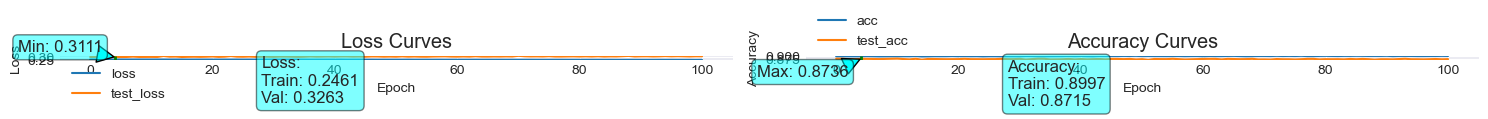

In [47]:
fn_plot_torch_hist(loss_df)

In [ ]:
y_true,y_pred=[],[]

model.eval()
with torch.inference_mode():

    for batch_idx,(train_X, train_y) in enumerate(train_loader):
        train_X,train_y = train_X.to(device), train_y.to(device)
        predict= model(train_X)
        y_pred.extend(torch.argmax(pred,dim=1).cpu().numpy())
        y_true.extend(train_y)

    y_true=np.concatenate(y_true)
        